# 02 — Tracking Comparison Across Profiles
#
# **Research question:** Does seeded browsing history change the
# tracking behavior a user encounters? Specifically:
#
#   1. Are seeded profiles tracked by MORE third-party hosts?
#   2. Do seeded profiles receive MORE persistent third-party cookies?
#   3. Are seeded profiles fingerprinted MORE aggressively?
#
# This notebook produces the headline figures and statistical tests
# that answer these questions.
#
# **Output:** Figures saved to `artifacts/figures/02_*.pdf`,
# statistics tables printed inline.

In [1]:
# %% Cell 1 — Setup
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from config import PROFILES, ALPHA, FIGURES_DIR
from src.utils.db import db_session

from src.analysis.trackers import (
    tracker_prevalence_by_profile,
    tracker_frequency_table,
    jaccard_similarity_matrix,
    differential_trackers,
)
from src.analysis.cookies import (
    cookie_counts_by_profile,
    cookie_lifespan_distribution,
    retargeting_cookie_presence,
    cookie_sync_summary,
)
from src.analysis.fingerprinting import (
    fingerprinter_summary,
    fingerprinter_top_scripts,
    detect_canvas_fingerprinters,
)
from src.analysis.statistics import (
    pairwise_battery,
    chi_square_batch,
    correct_pvalues,
)
from src.viz.tracker_plots import (
    apply_style,
    plot_prevalence_bars,
    plot_tracker_heatmap,
    plot_jaccard_matrix,
    plot_differential_trackers,
)
from src.viz.cookie_plots import (
    plot_first_vs_third_party,
    plot_lifespan_distribution,
    plot_retargeting_presence,
    plot_sync_summary,
    plot_fingerprinter_summary,
)

apply_style()
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Save all figures to a subdirectory of figures/ for this notebook.
FIG_DIR = FIGURES_DIR / "02_tracking_comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ## Section 1: Tracker prevalence (network-level)
#
# RQ1: Does seeded history change how many third-party hosts are
# contacted during browsing?


Tracker prevalence:
    profile  n_visits  n_unique_hosts  n_unique_etld1  hosts_per_visit  etld1_per_visit
    control       100            2041             954            20.41             9.54
    finance       100            1899             898            18.99             8.98
    fitness       100            1931             906            19.31             9.06
     gaming       100            1927             900            19.27             9.00
pop_culture       100            2017             952            20.17             9.52
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig01_tracker_breadth.pdf


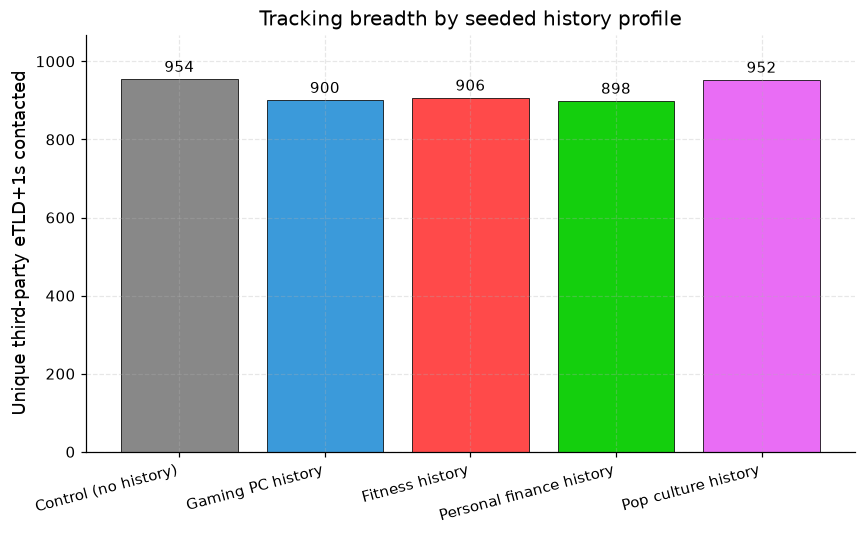

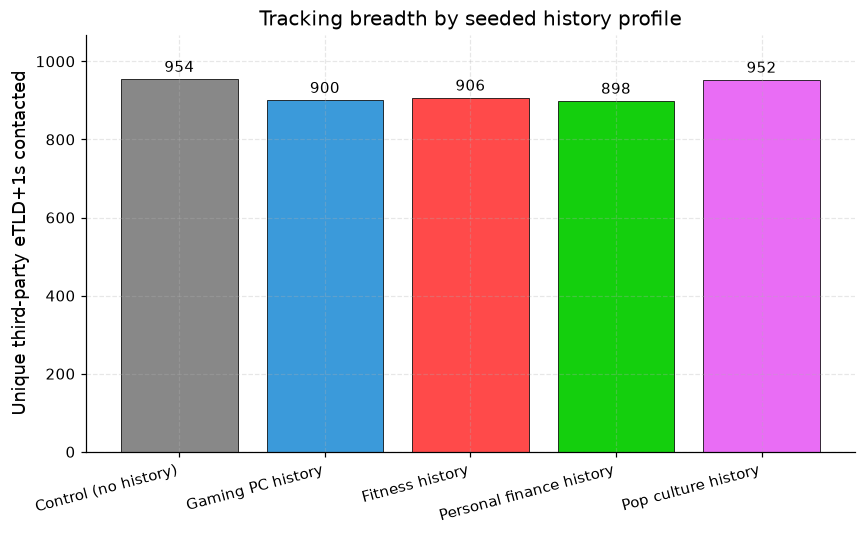

In [2]:
# %% Cell 2 — Headline metric
prev = tracker_prevalence_by_profile()
print("Tracker prevalence:")
print(prev.to_string(index=False))

plot_prevalence_bars(
    prev,
    value_col='n_unique_etld1',
    ylabel='Unique third-party eTLD+1s contacted',
    title='Tracking breadth by seeded history profile',
    save_path=FIG_DIR / 'fig01_tracker_breadth.pdf',
)

# ### Statistical test: do per-visit unique-host counts differ?
#
# We run Kruskal-Wallis (omnibus) followed by pairwise Mann-Whitney
# U tests with Bonferroni correction across the seeded-vs-control
# comparisons.

In [3]:
# %% Cell 3 — Statistics
stats_results = pairwise_battery('unique_hosts_per_visit')
print("\nStatistical results (Kruskal-Wallis + pairwise Mann-Whitney):")
print(stats_results[['test_name', 'comparison', 'statistic',
                     'p_value_corrected', 'effect_size',
                     'reject_null']].to_string(index=False))


Statistical results (Kruskal-Wallis + pairwise Mann-Whitney):
       test_name                                     comparison   statistic  p_value_corrected  effect_size  reject_null
Kruskal-Wallis H             5 profiles: unique_hosts_per_visit    0.155888           0.997116       0.0000        False
  Mann-Whitney U      gaming vs control: unique_hosts_per_visit 4887.000000           1.000000       0.0226        False
  Mann-Whitney U     fitness vs control: unique_hosts_per_visit 4877.000000           1.000000       0.0246        False
  Mann-Whitney U     finance vs control: unique_hosts_per_visit 4850.000000           1.000000       0.0300        False
  Mann-Whitney U pop_culture vs control: unique_hosts_per_visit 4900.000000           1.000000       0.0200        False


# **Interpretation guide:**
#   - Kruskal-Wallis significant + all pairwise significant →
#     each seeded profile differs from control
#   - Kruskal-Wallis significant but only some pairs → only those
#     profiles' seeding had measurable effect
#   - Kruskal-Wallis non-significant → no overall effect; report
#     null result honestly


# ## Section 2: Tracker identity (which trackers, not just how many)

  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig02_tracker_heatmap.pdf


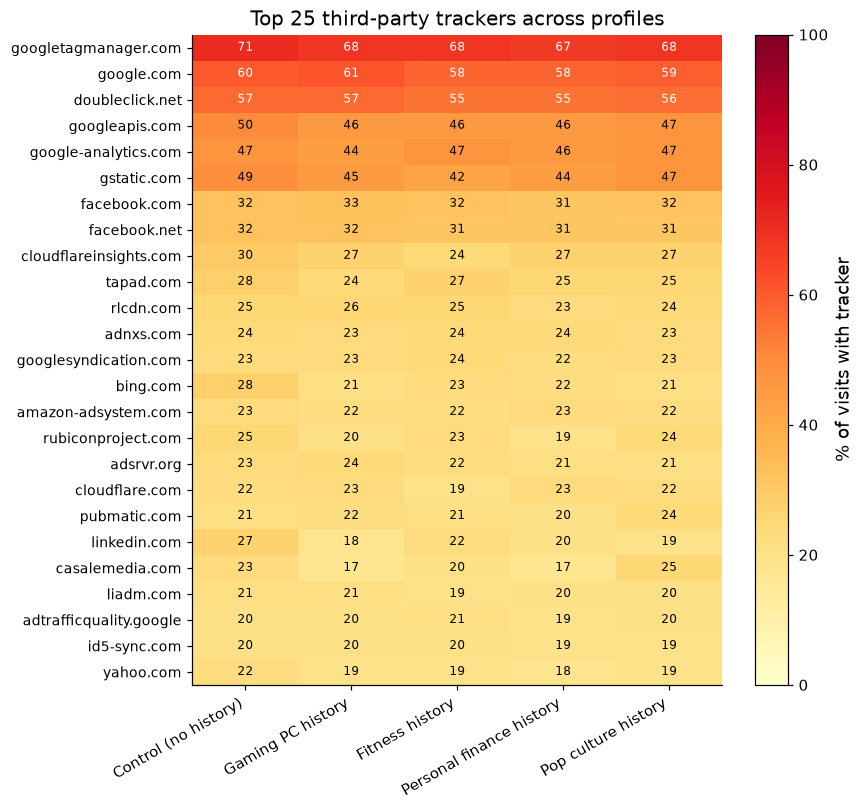

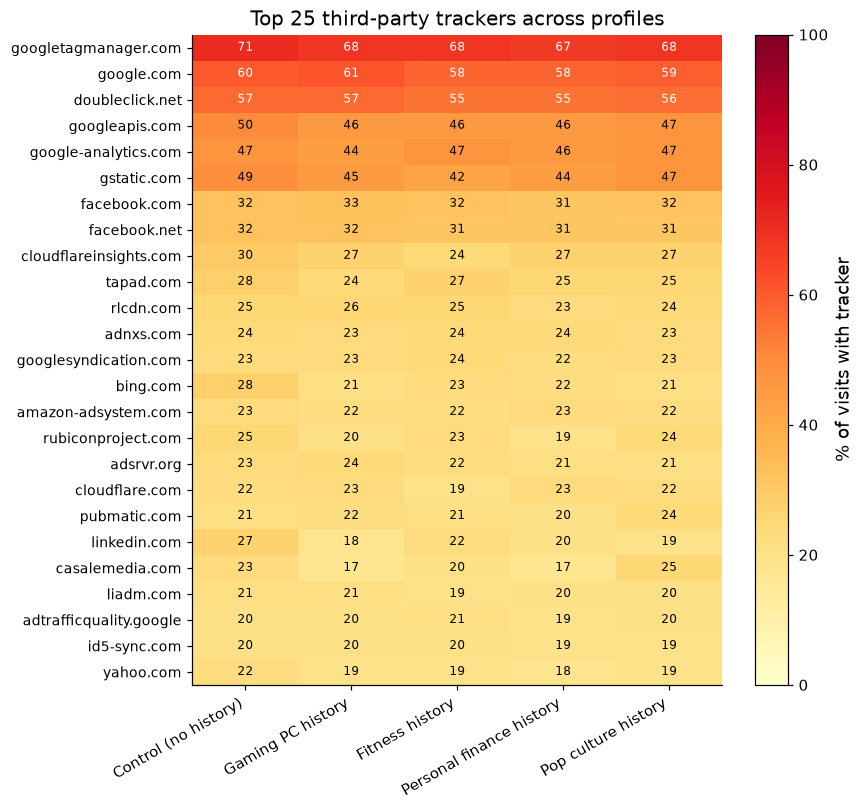

In [4]:
# %% Cell 4 — Top tracker heatmap
freq = tracker_frequency_table(top_n=25)
plot_tracker_heatmap(
    freq,
    top_n=25,
    title='Top 25 third-party trackers across profiles',
    save_path=FIG_DIR / 'fig02_tracker_heatmap.pdf',
)

Jaccard similarity of tracker sets:
             control  finance  fitness  gaming  pop_culture
control        1.000    0.826    0.818   0.834        0.803
finance        0.826    1.000    0.819   0.833        0.839
fitness        0.818    0.819    1.000   0.826        0.823
gaming         0.834    0.833    0.826   1.000        0.823
pop_culture    0.803    0.839    0.823   0.823        1.000
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig03_jaccard.pdf


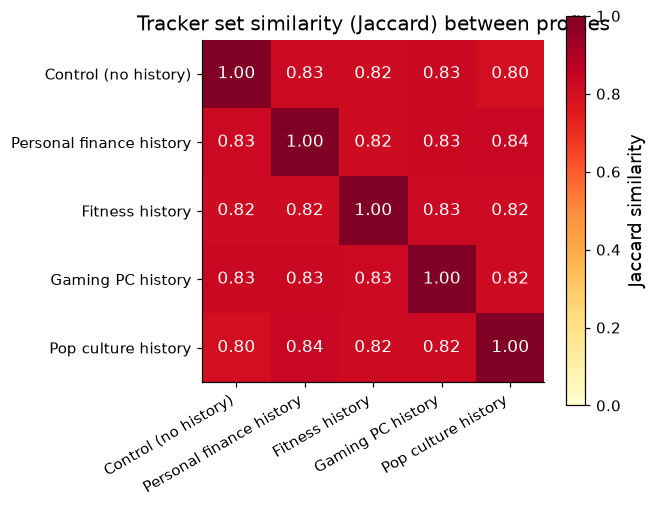

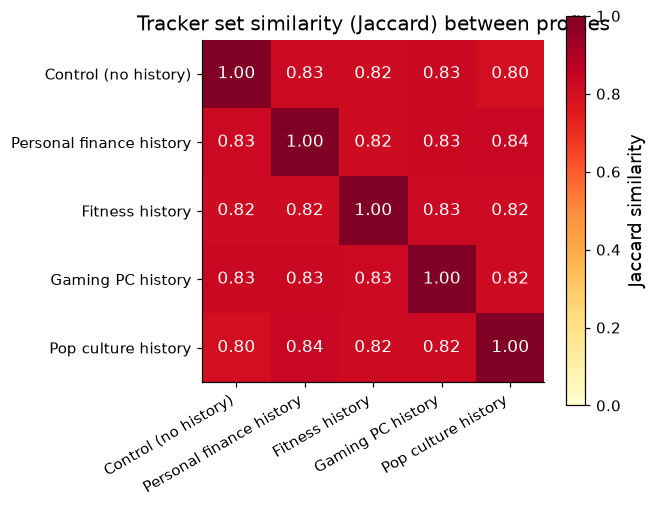

In [5]:
# %% Cell 5 — Set similarity
jaccard = jaccard_similarity_matrix()
print("Jaccard similarity of tracker sets:")
print(jaccard.round(3).to_string())

plot_jaccard_matrix(
    jaccard,
    save_path=FIG_DIR / 'fig03_jaccard.pdf',
)

# ## Section 3: Differential trackers (the "smoking gun" trackers)
#
# For each seeded profile, identify trackers that appear
# disproportionately compared to control, and confirm with
# chi-square tests.


Differential trackers: gaming vs control

Top 15 by lift:
                etld1  visits_a  visits_b  lift  delta
mediagotechnology.com       5.0       0.0 6.000    5.0
       pro-market.net       6.0       1.0 3.500    5.0
           amazon.dev       5.0       1.0 3.000    4.0
            clinch.co       6.0       2.0 2.333    4.0
           truste.com       7.0       3.0 2.000    4.0
         trustarc.com      10.0       5.0 1.833    5.0
    ads-tinyorbit.com       7.0       4.0 1.600    3.0
         ftstatic.com       7.0       4.0 1.600    3.0
     flashtalking.com       8.0       5.0 1.500    3.0
          mookie1.com       5.0       3.0 1.500    2.0
              dv.tech       6.0       4.0 1.400    2.0
       quantcount.com       6.0       4.0 1.400    2.0
     doubleverify.com      14.0      10.0 1.364    4.0
             rqtrk.eu       8.0       6.0 1.286    2.0
     richaudience.com      13.0      10.0 1.273    3.0

Statistical confirmation:
  Of top 30 differential trackers,

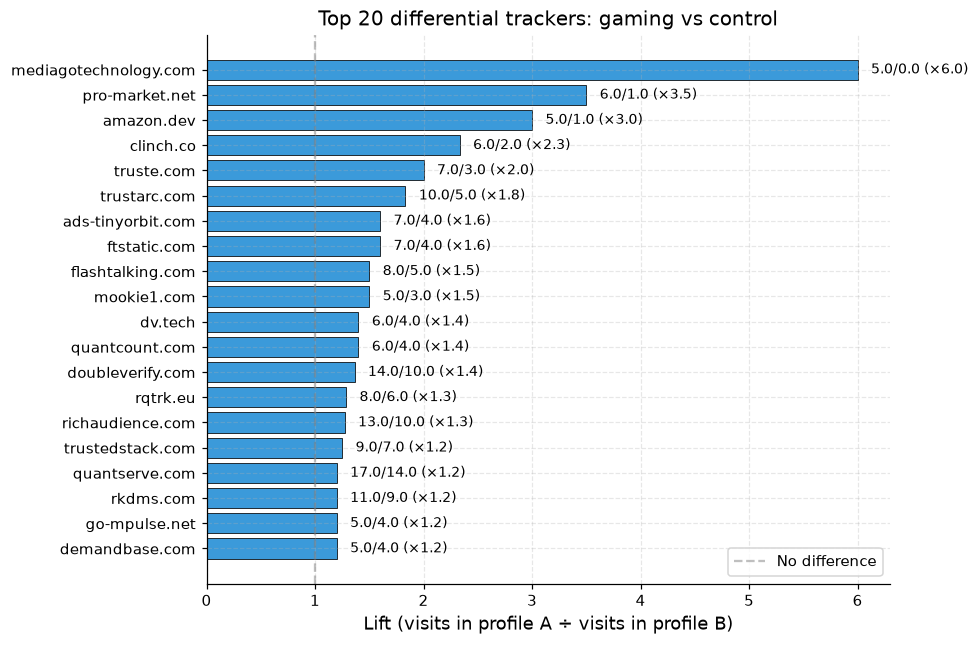

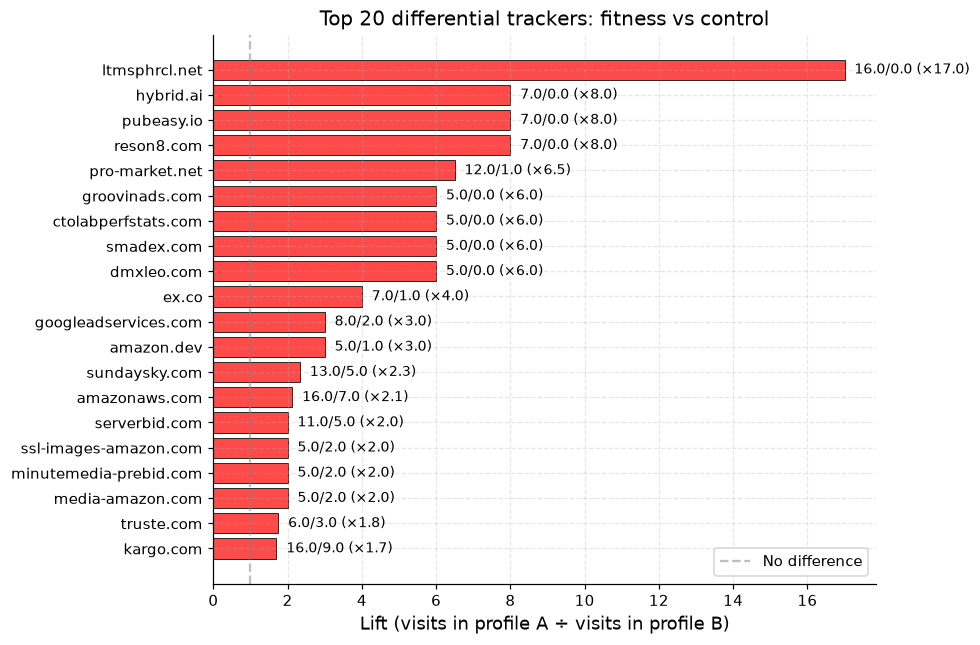

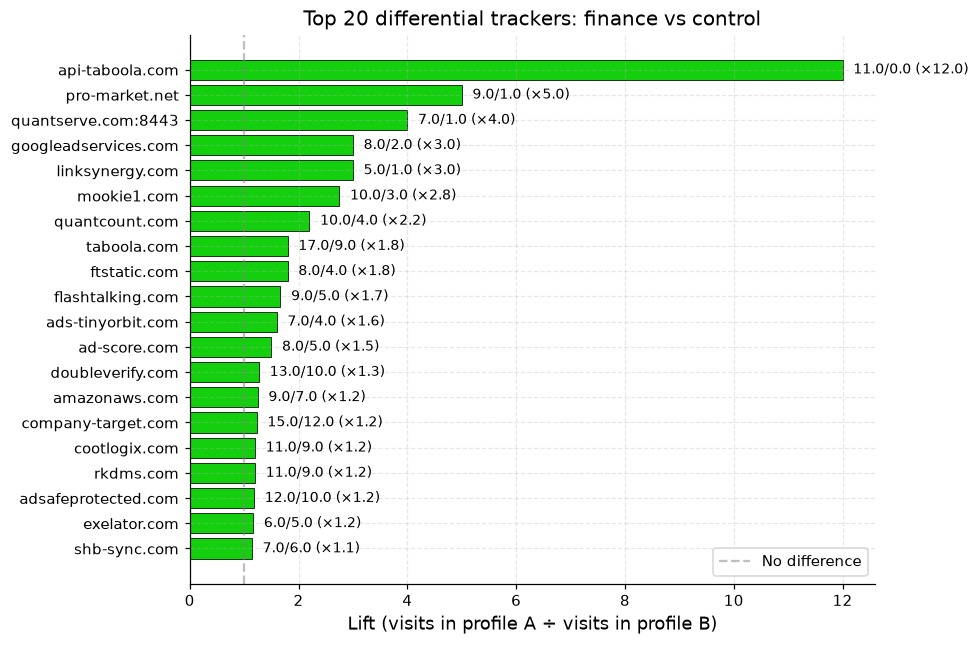

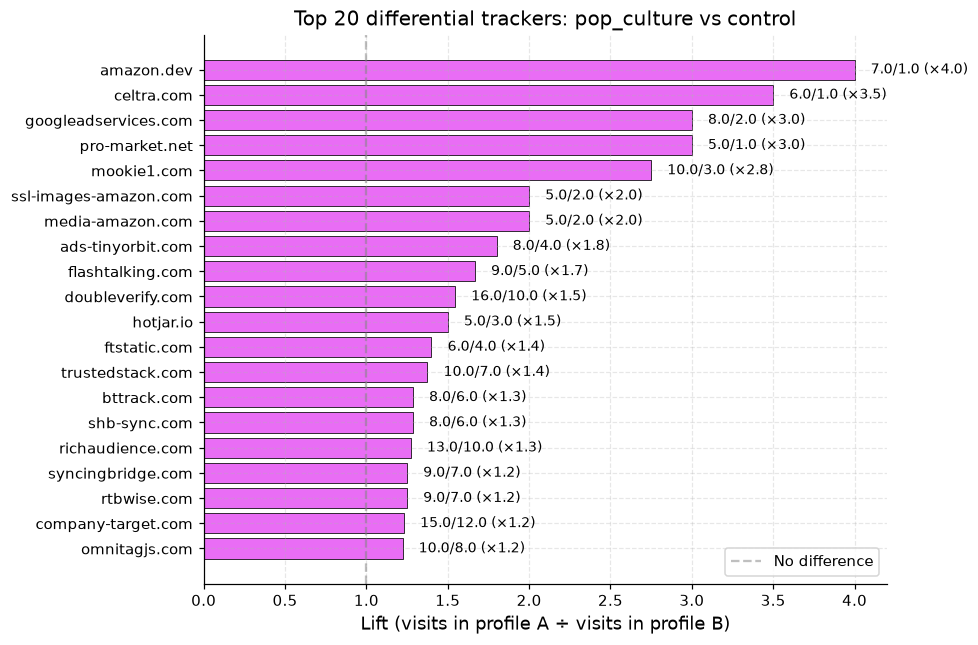

In [6]:
# %% Cell 6 — Per-seeded-profile differential analysis
for profile in PROFILES:
    if profile == 'control':
        continue
    print(f"\n{'='*60}")
    print(f"Differential trackers: {profile} vs control")
    print('='*60)

    diff = differential_trackers(profile, 'control', min_visits=5)
    print(f"\nTop 15 by lift:")
    print(diff.head(15)[['etld1', 'visits_a', 'visits_b', 'lift', 'delta']]
              .to_string(index=False))

    # Statistical confirmation on the top differential candidates
    top_trackers = diff.head(30)['etld1'].tolist()
    chi_results = chi_square_batch(profile, 'control', top_trackers)
    n_sig = chi_results['reject_null'].sum()
    print(f"\nStatistical confirmation:")
    print(f"  Of top 30 differential trackers, {n_sig} significant "
          f"after Bonferroni correction (α = {ALPHA})")

    sig_only = chi_results[chi_results['reject_null']].head(10)
    if not sig_only.empty:
        print(f"\nTop significant trackers ({profile}):")
        print(sig_only[['comparison', 'statistic',
                        'p_value_corrected', 'effect_size']]
                  .to_string(index=False))

    plot_differential_trackers(
        diff, f'{profile} vs control', top_n=20,
        save_path=FIG_DIR / f'fig04_diff_{profile}.pdf',
    )

# ## Section 4: Cookie behavior

Cookie counts by profile:
    profile  n_total  n_first_party  n_third_party  n_unique_hosts  pct_third_party
    control    52465         8871.0        43594.0             670            83.09
    finance    26170         7616.0        18554.0             581            70.90
    fitness    26674         8212.0        18462.0             583            69.21
     gaming    24129         8638.0        15491.0             591            64.20
pop_culture    25666         8158.0        17508.0             626            68.21
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig05_cookies_fp_tp.pdf


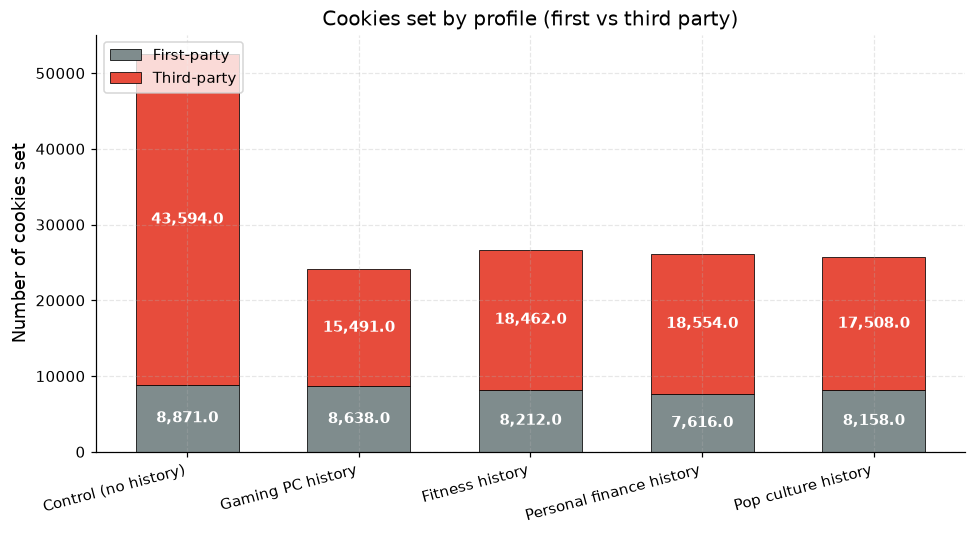

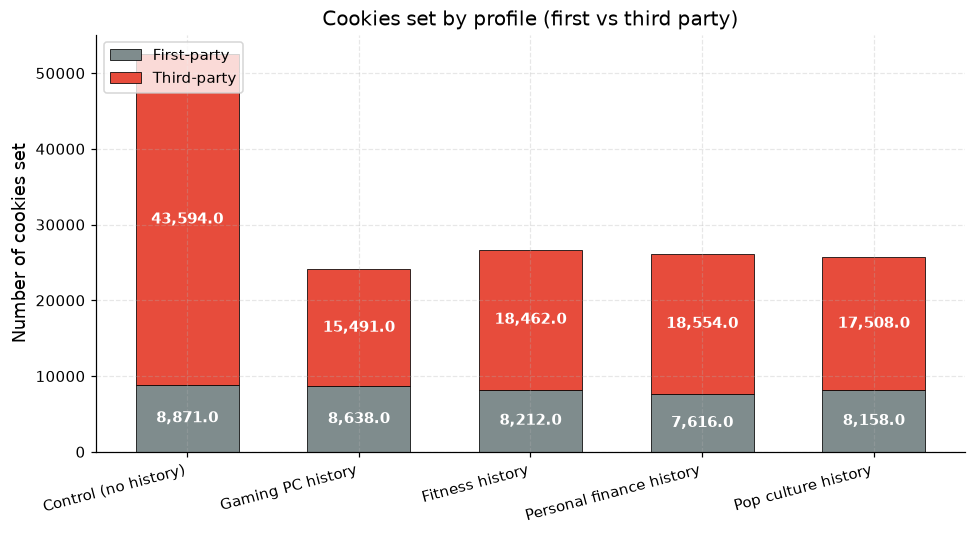

In [7]:
# %% Cell 7 — First vs third party
cookie_counts = cookie_counts_by_profile()
print("Cookie counts by profile:")
print(cookie_counts.to_string(index=False))

plot_first_vs_third_party(
    cookie_counts,
    save_path=FIG_DIR / 'fig05_cookies_fp_tp.pdf',
)


  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig06_cookie_lifespan_pct.pdf
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig06_cookie_lifespan_raw.pdf


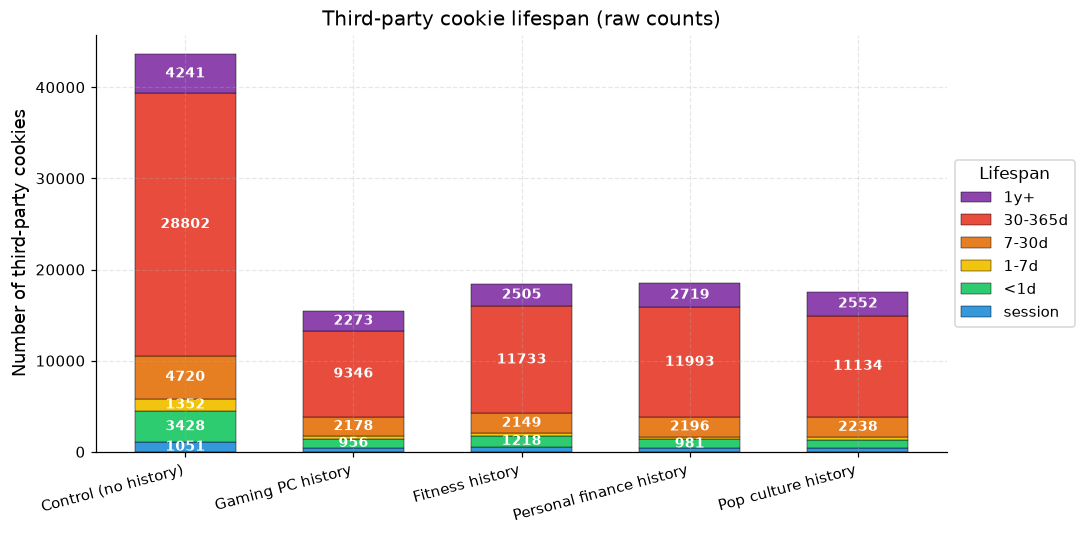

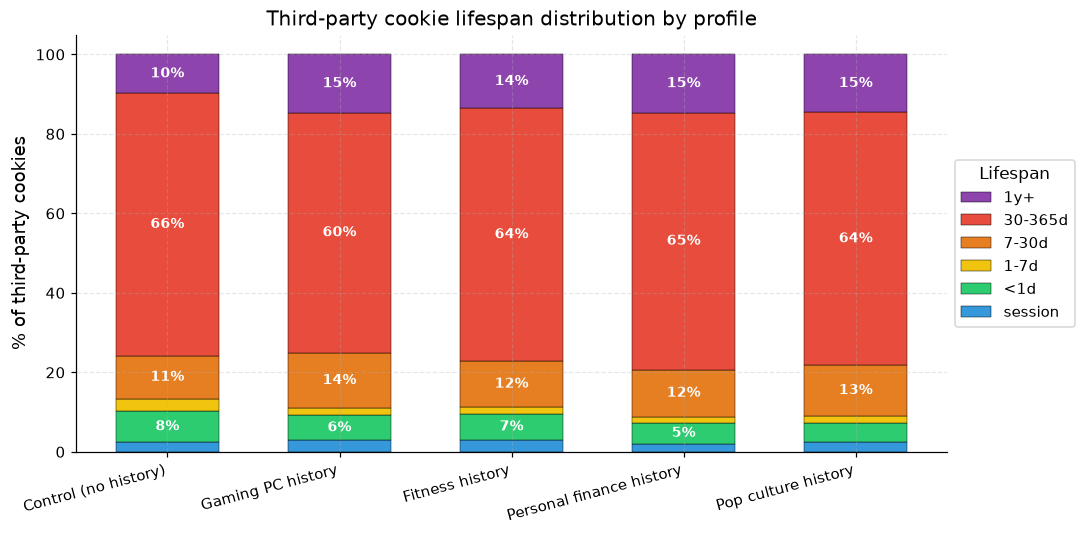

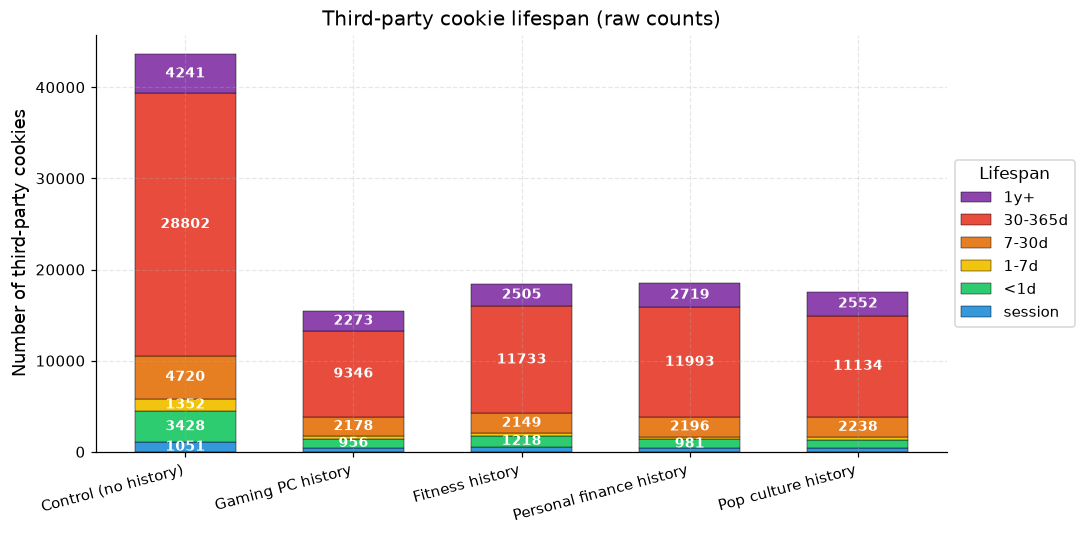

In [8]:
# %% Cell 8 — Lifespan distribution
lifespan = cookie_lifespan_distribution(third_party_only=True)
plot_lifespan_distribution(
    lifespan, normalize=True,
    save_path=FIG_DIR / 'fig06_cookie_lifespan_pct.pdf',
)
plot_lifespan_distribution(
    lifespan, normalize=False,
    title='Third-party cookie lifespan (raw counts)',
    save_path=FIG_DIR / 'fig06_cookie_lifespan_raw.pdf',
)

# ### Statistical test on third-party cookie counts

In [9]:
# %% Cell 9
tp_stats = pairwise_battery('third_party_cookies_per_visit')
print("\nThird-party cookies per visit (statistics):")
print(tp_stats[['test_name', 'comparison', 'p_value_corrected',
                'effect_size', 'reject_null']].to_string(index=False))


Third-party cookies per visit (statistics):
       test_name                                         comparison  p_value_corrected  effect_size  reject_null
Kruskal-Wallis H          2 profiles: third_party_cookies_per_visit           0.625063     0.000000        False
  Mann-Whitney U shopping vs control: third_party_cookies_per_visit           0.625161     0.019287        False


# ## Section 5: Retargeting network presence

Retargeting cookies by network and profile:
    profile         retargeter  n_cookies  n_visits_affected
    control rubiconproject.com       4647                 25
    control       pubmatic.com       4323                 18
    control          adnxs.com       1194                 24
    control        taboola.com       1100                  7
    control    casalemedia.com       1010                 22
    control          rlcdn.com        546                 23
    control       outbrain.com        233                 15
    control      bidswitch.net        216                 19
    control    doubleclick.net        193                 43
    control         adroll.com         68                  9
    control         criteo.com         39                 19
    finance          adnxs.com       1976                 24
    finance        taboola.com       1472                 17
    finance       pubmatic.com        700                 17
    finance rubiconproject.com        671

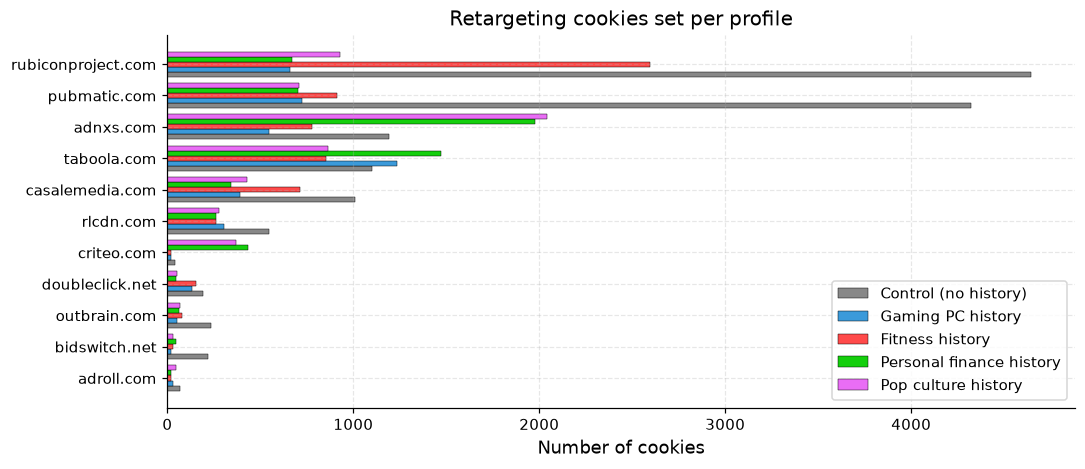

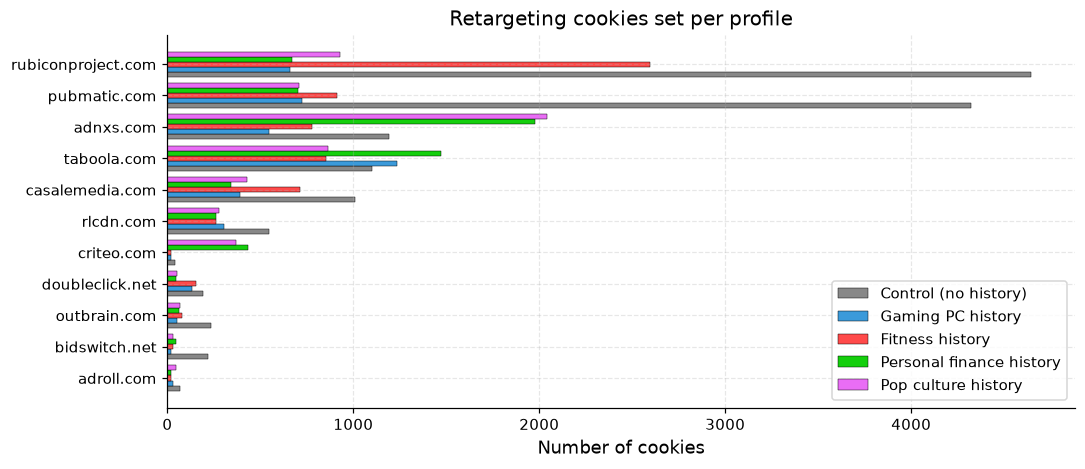

In [9]:
# %% Cell 10
retarg = retargeting_cookie_presence()
print("Retargeting cookies by network and profile:")
print(retarg.to_string(index=False))

plot_retargeting_presence(
    retarg, metric='n_cookies',
    title='Retargeting cookies set per profile',
    save_path=FIG_DIR / 'fig07_retargeting_cookies.pdf',
)

# ## Section 6: Cookie syncing

Cookie sync activity:
    profile  n_sync_events  n_visits_with_syncs  avg_hosts_per_sync
    control            413                   42                2.48
    finance            186                   39                2.35
    fitness            171                   36                2.34
     gaming            181                   41                2.27
pop_culture            163                   40                2.31
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig08_sync_summary.pdf


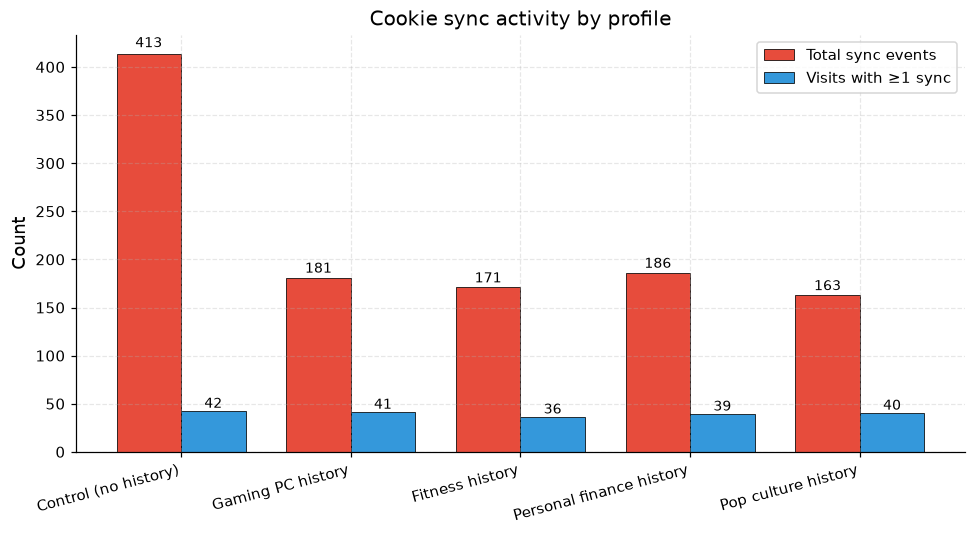

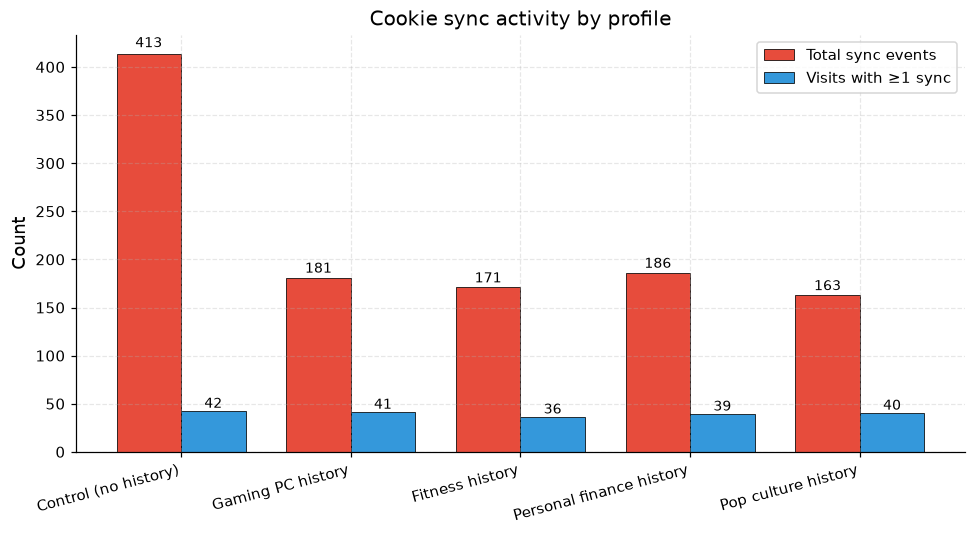

In [10]:
# %% Cell 11
syncs = cookie_sync_summary()
print("Cookie sync activity:")
print(syncs.to_string(index=False))

plot_sync_summary(
    syncs,
    save_path=FIG_DIR / 'fig08_sync_summary.pdf',
)

# ## Section 7: Fingerprinting
#
# Even when cookies are cleared, fingerprinting persists identity.
# Do seeded profiles encounter more aggressive fingerprinting?

Fingerprinting scripts encountered:
    profile  n_canvas_fp_scripts  n_audio_fp_scripts  n_navigator_fp_scripts  canvas_fp_visits  audio_fp_visits  navigator_fp_visits
    control                   46                   0                     258                47                0                  383
     gaming                   45                   0                     280                45                0                  415
    fitness                   43                   0                     238                44                0                  349
    finance                   49                   0                     258                50                0                  390
pop_culture                   50                   0                     268                51                0                  386
  ✓ Saved figure → C:\Users\finkgr1\Desktop\Tracking Analysis\artifacts\figures\02_tracking_comparison\fig09_fingerprinter_summary.pdf


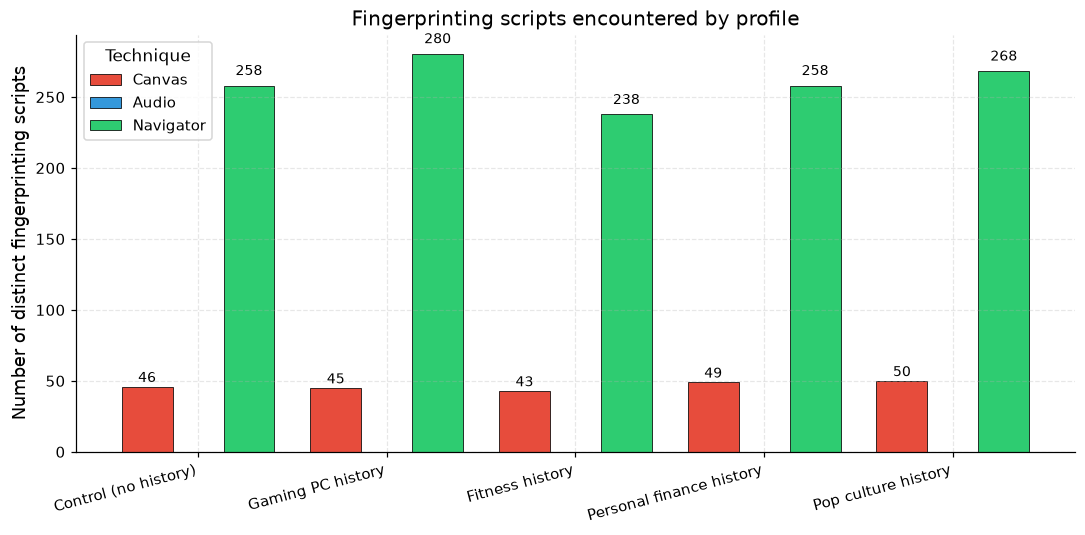

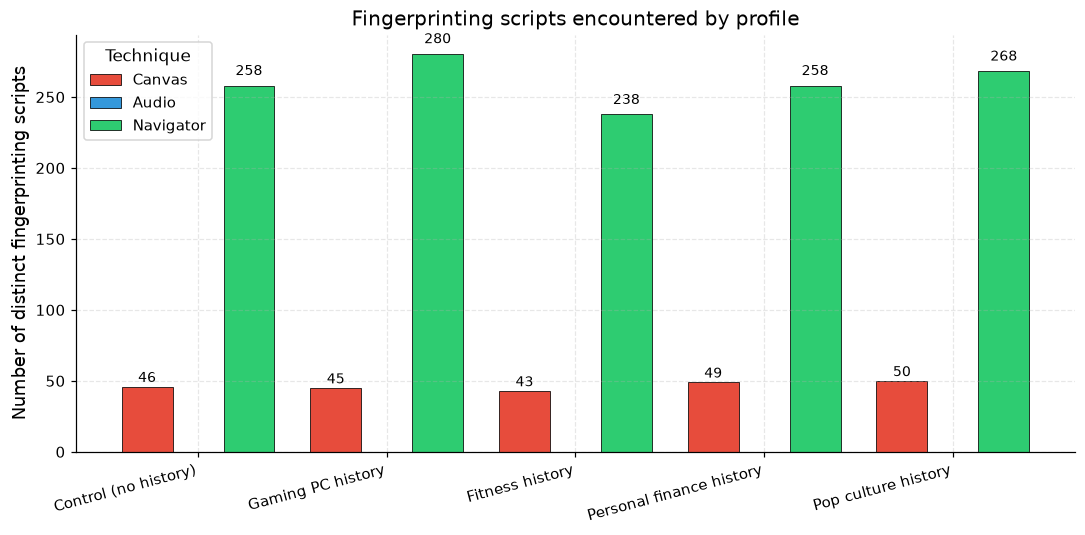

In [11]:
# %% Cell 12 — Summary
fp_summary = fingerprinter_summary()
print("Fingerprinting scripts encountered:")
print(fp_summary.to_string(index=False))

plot_fingerprinter_summary(
    fp_summary,
    save_path=FIG_DIR / 'fig09_fingerprinter_summary.pdf',
)

In [12]:
# %% Cell 13 — Top scripts
top_fp = fingerprinter_top_scripts(top_n=20)
print("\nTop 20 fingerprinting scripts (all profiles):")
print(top_fp.to_string(index=False))



Top 20 fingerprinting scripts (all profiles):
                                                                                           script_url technique  total_visits  profiles_seen
                                                                                                      navigator            75              5
                                                                          https://bat.bing.com/bat.js navigator            71              5
                                                         https://scripts.clarity.ms/0.8.66/clarity.js navigator            49              5
                                                     https://static.adsafeprotected.com/sca.17.6.4.js navigator            45              5
                                                                https://static.ads-twitter.com/uwt.js navigator            35              5
                                            https://script.hotjar.com/modules.fa52fb4272e01466771f.js navig

# ## Section 8: Summary of findings

In [13]:
# %% Cell 14
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)
print(f"\nProfiles analyzed: {', '.join(PROFILES)}")
print(f"Significance threshold: α = {ALPHA} (Bonferroni-corrected)")

print("\n— RQ1 (Network) —")
print(f"  Unique trackers per profile:")
for _, row in prev.iterrows():
    print(f"    {row['profile']:10s}: {row['n_unique_etld1']:4d} eTLD+1s, "
          f"{row['etld1_per_visit']:.1f} per visit")
n_sig_network = (stats_results[stats_results['test_name'] == 'Mann-Whitney U']
                 ['reject_null'].sum())
print(f"  {n_sig_network} of {len(PROFILES) - 1} seeded profiles show "
      f"significantly different unique-host counts vs control.")

print("\n— RQ2 (Cookies) —")
for _, row in cookie_counts.iterrows():
    print(f"    {row['profile']:10s}: {row['n_third_party']:5d} 3p cookies "
          f"({row['pct_third_party']}%)")

print("\n— RQ3 (Fingerprinting) —")
for _, row in fp_summary.iterrows():
    total = (row['n_canvas_fp_scripts'] + row['n_audio_fp_scripts']
             + row['n_navigator_fp_scripts'])
    print(f"    {row['profile']:10s}: {total:3d} fingerprinting scripts "
          f"(canvas={row['n_canvas_fp_scripts']}, "
          f"audio={row['n_audio_fp_scripts']}, "
          f"navigator={row['n_navigator_fp_scripts']})")

print("\nAll figures saved to:", FIG_DIR.resolve())

SUMMARY OF FINDINGS

Profiles analyzed: control, gaming, fitness, finance, pop_culture
Significance threshold: α = 0.05 (Bonferroni-corrected)

— RQ1 (Network) —
  Unique trackers per profile:
    control   :  954 eTLD+1s, 9.5 per visit
    finance   :  898 eTLD+1s, 9.0 per visit
    fitness   :  906 eTLD+1s, 9.1 per visit
    gaming    :  900 eTLD+1s, 9.0 per visit
    pop_culture:  952 eTLD+1s, 9.5 per visit
  0 of 4 seeded profiles show significantly different unique-host counts vs control.

— RQ2 (Cookies) —


ValueError: Unknown format code 'd' for object of type 'float'